In [1]:
import matplotlib.pyplot as plt
from rotations import rot_z
from helpers import load_dataloader, predict, rotate_image, optimize_latents_of_image, lerp, get_newest_model
from reni.utils.utils import find_nerfstudio_project_root
from reni.utils.colourspace import linear_to_sRGB

import os
from pathlib import Path
from helpers import models
from veni.utils.helpers import load_model, device
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
from PIL import Image
import numpy as np
import statistics
import pickle

project_root = find_nerfstudio_project_root(Path(os.getcwd()))
os.chdir(project_root)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{extpfeil}",
    "font.family": "serif",
})

from pathlib import Path

import numpy as np
import pyexr
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

from nerfstudio.cameras.cameras import Cameras, CameraType
from reni.field_components.field_heads import RENIFieldHeadNames
from reni.illumination_fields.reni_illumination_field import RENIField, RENIFieldConfig
from reni.model_components.illumination_samplers import EquirectangularSamplerConfig
from reni.model_components.shaders import BlinnPhongShader
from reni.utils.colourspace import linear_to_sRGB
from reni.utils.utils import find_nerfstudio_project_root
from torchmetrics.image import PeakSignalNoiseRatio


from ns_reni.notebooks.inverse_rendering_demo import load_pretrained_reni_decoder, load_environment_map, load_normal_map, create_camera_and_view_directions, render_with_environment, decode_reni_to_envmap, save_comparison_image

In [2]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
#ckpt_path = Path("outputs/reni/reni_plus_plus_models/latent_dim_9")
#ckpt_path = Path("outputs/reni/reni_plus_plus_models/latent_dim_49")
ckpt_path = Path("outputs/reni/reni_plus_plus_models/latent_dim_100")
ckpt_step = 50000
#ckpt_path = Path("outputs/veni/veni_27/")
#ckpt_path = Path("outputs/veni/veni_147/")
#ckpt_path = Path("outputs/veni/veni_300/")
#ckpt_step = 80000

data_dir = project_root / "data" / "RENI_HDR"
env_map_path = data_dir / "test" / "00006.exr"  # Use a validation env map # 5 was the best so far.
normal_map_path = data_dir / "3d_models" / "normal_maps" / "bunny_normals.exr"

# Hyperparameters
image_size = 128
illumination_width = 128
illumination_height = 64
num_steps = 5000
lr = 0.05
save_every = 50
specular_term = 0.8 # 0.8
shininess = 500.0



def optimize_inverse(reni_field, num_steps, latent_dim, env_map_path, lr = 0.05, specular_term=specular_term):
    
    # Load ground truth environment map
    print("\n[2/5] Loading environment map...")
    gt_envmap = load_environment_map(
        env_map_path, illumination_height, illumination_width
    )
    gt_envmap = gt_envmap.to(device)
    print(f"  Environment map shape: {gt_envmap.shape}")

    # Load normal map
    print("\n[3/5] Loading normal map...")
    normals, mask = load_normal_map(normal_map_path, image_size)
    normals = normals.to(device)
    mask = mask.to(device)
    print(f"  Normal map shape: {normals.shape}")
    
    # Setup illumination sampler and shader
    print("\n[4/5] Setting up rendering components...")
    sampler = EquirectangularSamplerConfig(
        width=illumination_width,
        apply_random_rotation=False,
        remove_lower_hemisphere=False,
    ).setup()
    
    shader = BlinnPhongShader()
    
    # Get light directions
    ray_samples = sampler.generate_direction_samples()
    light_directions = ray_samples.frustums.directions.to(device)
    light_directions = light_directions / torch.norm(
        light_directions, dim=-1, keepdim=True
    )
    
    # Get view directions
    view_directions = create_camera_and_view_directions(image_size, device)
    
    # Render ground truth image
    print("\n[5/5] Rendering ground truth...")
    with torch.no_grad():
        gt_render = render_with_environment(
            normals,
            mask,
            gt_envmap,
            light_directions,
            view_directions,
            shader,
            specular_term,
            shininess,
        )
    print(f"  GT render shape: {gt_render.shape}")
    
    # Initialize learnable latent codes (start from zero = prior mean)
    print("\n" + "=" * 60)
    print("Starting optimization...")
    print("=" * 60)
    
    latent_codes = nn.Parameter(torch.zeros(reni_field.latent_dim, 3, device=device))
    scale = nn.Parameter(torch.zeros(1, device=device))  # log scale
    
    optimizer = torch.optim.Adam([latent_codes, scale], lr=lr)
    #scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: 0.95**epoch+0.1)
    
    l2_loss_fn = nn.MSELoss()
    l1_loss_fn = nn.L1Loss()
    cosine_sim = nn.CosineSimilarity(dim=-1)
    psnr_fn = PeakSignalNoiseRatio()
    
    # Optimization loop
    pbar = tqdm(range(num_steps + 1), desc="Optimizing")
    for step in pbar:
        optimizer.zero_grad()
    
        # Decode latents through RENI
        pred_envmap = decode_reni_to_envmap(
            reni_field, latent_codes, torch.exp(scale), sampler, device
        )
    
        # Render with predicted environment
        pred_render = render_with_environment(
            normals,
            mask,
            pred_envmap,
            light_directions,
            view_directions,
            shader,
            specular_term,
            shininess,
        )
    
        # Compute loss 
        q = torch.quantile(gt_render.flatten(), 0.98)
        gt_srgb = linear_to_sRGB(gt_render, q=q, clamp=False)
        pred_srgb = linear_to_sRGB(pred_render, q=q, clamp=False)
    
        rgb_loss = l2_loss_fn(pred_srgb, gt_srgb)
        cos_loss = (
            1.0 - cosine_sim(pred_srgb.reshape(-1, 3), gt_srgb.reshape(-1, 3)).mean()
        )
        prior_loss = torch.mean(latent_codes**2)
        #rgb_log_loss = l2_loss_fn(torch.log(pred_render), torch.log(gt_render))
        rgb_log_loss = l1_loss_fn(torch.log(pred_render), torch.log(gt_render))
    
    
        #total_loss = 100.0 * rgb_loss #+ 1.0 * cos_loss + 0.001 * prior_loss
        total_loss = 100*rgb_log_loss
    
        total_loss.backward()
        optimizer.step()
        #scheduler.step()
        
        log_psnr = psnr_fn(preds=torch.log(pred_envmap).cpu(), target=torch.log(gt_envmap).cpu())
    
        pbar.set_postfix(
            {
                "loss": f"{total_loss.item():.4f}",
                "rgb": f"{rgb_loss.item():.4f}",
                "scale": f"{torch.exp(scale).item():.2f}",
                "psnr": f"{log_psnr.item():.2f}",
            }
        )
    
    return latent_codes.detach(), scale.detach(), log_psnr.item()
reni_field = load_pretrained_reni_decoder(Path("outputs/reni/reni_plus_plus_models/latent_dim_100"), 50000, device, latent_dim=100)
latents, scale, psnr = optimize_inverse(reni_field, 100, 100, data_dir / "test" / "00006.exr")


Using device: cuda
Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/reni/reni_plus_plus_models/latent_dim_100/nerfstudio_models/step-000050000.ckpt

[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|████████████████████████████████████| 101/101 [00:16<00:00,  5.95it/s, loss=3.7213, rgb=0.0004, scale=0.83, psnr=22.46]


In [3]:
#latents, scale = optimize_inverse(Path("outputs/reni/reni_plus_plus_models/latent_dim_100"), 50000, 500)
env_map_path = data_dir / "test" / "00005.exr"

gt_envmap = load_environment_map(
    env_map_path, illumination_height, illumination_width
)
gt_envmap = gt_envmap.to(device)

def render_image(gt_envmap, image_size,specular_term=specular_term):
    device = gt_envmap.device
    normals, mask = load_normal_map(normal_map_path, image_size)
    normals = normals.to(device)
    mask = mask.to(device)
    
    sampler = EquirectangularSamplerConfig(
        width=illumination_width,
        apply_random_rotation=False,
        remove_lower_hemisphere=False,
    ).setup()
    
    shader = BlinnPhongShader()
    
    ray_samples = sampler.generate_direction_samples()
    light_directions = ray_samples.frustums.directions.to(device)
    light_directions = light_directions / torch.norm(
        light_directions, dim=-1, keepdim=True
    )
    
    view_directions = create_camera_and_view_directions(image_size, device)
    
    with torch.no_grad():
        gt_render = render_with_environment(
            normals,
            mask,
            gt_envmap,
            light_directions,
            view_directions,
            shader,
            specular_term,
            shininess,
        )
    return gt_render, mask


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2099266..1.7562145].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024119066..4.0370126].


Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/reni/reni_plus_plus_models/latent_dim_9/nerfstudio_models/step-000050000.ckpt

[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|████████████████████████████████████| 501/501 [01:17<00:00,  6.50it/s, loss=6.7814, rgb=0.0019, scale=0.18, psnr=23.22]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.23256949..1.7332422].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1323801..1.5689466].


Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/veni/veni_27/nerfstudio_models/step-000080000.ckpt

[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|████████████████████████████████████| 501/501 [01:21<00:00,  6.17it/s, loss=3.4900, rgb=0.0008, scale=0.25, psnr=24.92]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21181473..1.7463367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10884941..1.3018316].


...

Optimizing: 100%|████████████████████████████████████| 501/501 [01:24<00:00,  5.93it/s, loss=2.5980, rgb=0.0006, scale=0.35, psnr=25.29]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21158764..1.715976].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10281641..1.3486295].


Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/reni/reni_plus_plus_models/latent_dim_100/nerfstudio_models/step-000050000.ckpt

[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|████████████████████████████████████| 501/501 [01:18<00:00,  6.41it/s, loss=2.0878, rgb=0.0002, scale=0.96, psnr=24.68]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.20977923..1.7374667].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.097407036..2.253386].


Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/veni/veni_300/nerfstudio_models/step-000080000.ckpt

[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|████████████████████████████████████| 501/501 [01:18<00:00,  6.40it/s, loss=1.9651, rgb=0.0003, scale=0.42, psnr=26.19]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21055481..1.6844485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08064584..1.5231496].


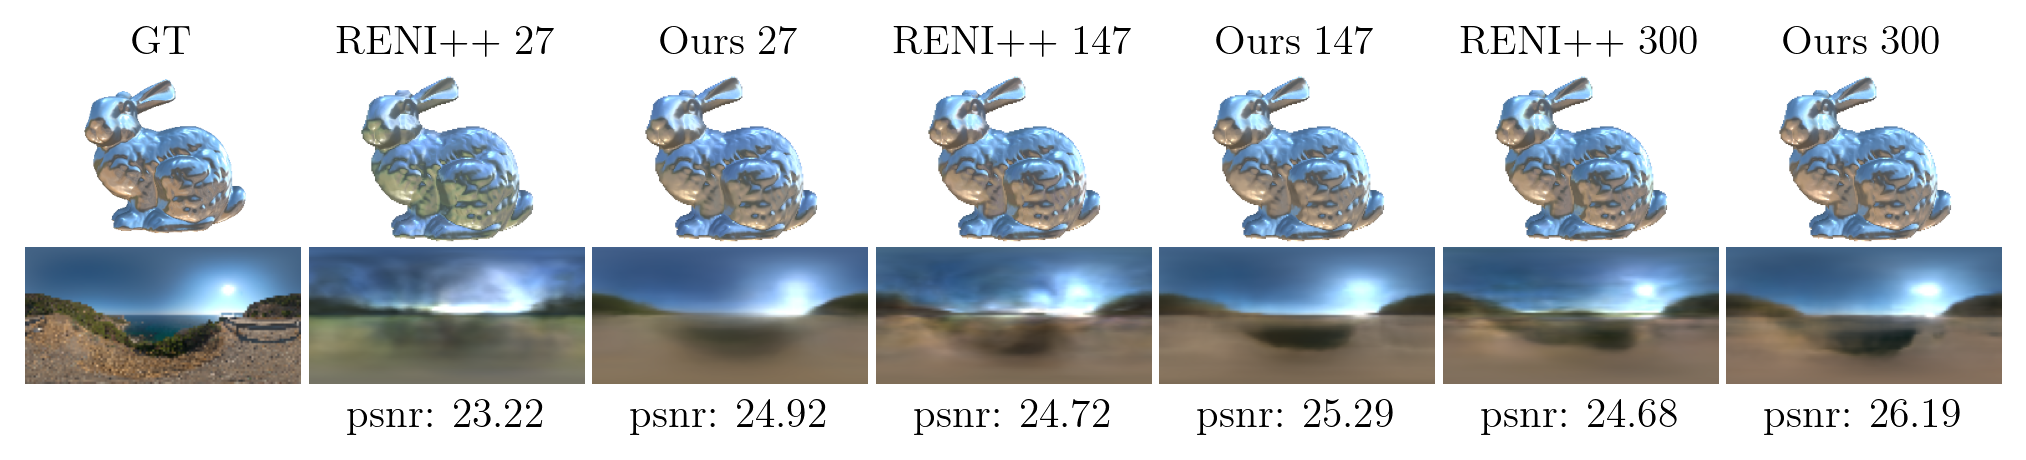

In [4]:
#latents, scale = optimize_inverse(Path("outputs/reni/reni_plus_plus_models/latent_dim_100"), 50000, 500)
env_map_path = data_dir / "test" / "00005.exr"

gt_envmap = load_environment_map(
    env_map_path, illumination_height, illumination_width
)
gt_envmap = gt_envmap.to(device)

models = [
    (9, "outputs/reni/reni_plus_plus_models/latent_dim_9", "RENI++ 27", 50000),
    (9, "outputs/veni/veni_27/", "Ours 27", 80000),
    (49, "outputs/reni/reni_plus_plus_models/latent_dim_49", "RENI++ 147", 50000),
    (49, "outputs/veni/veni_147/", "Ours 147", 80000),
    (100, "outputs/reni/reni_plus_plus_models/latent_dim_100", "RENI++ 300", 50000),
    (100, "outputs/veni/veni_300/", "Ours 300", 80000)
]

size_mult = 0.6
fig = plt.figure(figsize=(17*size_mult,2.7*size_mult), dpi=250)
gs0 = gridspec.GridSpec(2,len(models)+1, figure=fig, wspace=0.03, hspace=0.00, height_ratios=[1.2,1])

with torch.no_grad():
    gt_render, mask = render_image(gt_envmap.cpu(), 256)

q_r = torch.quantile(gt_render.flatten(), 0.98)
gt_srgb = linear_to_sRGB(gt_render, q=q_r, clamp=False).cpu()
gt_srgb[mask==0] = 1
gt_srgb = gt_srgb[7:-20,:]

q_e = torch.quantile(gt_envmap.flatten(), 0.98)
env_srgb = linear_to_sRGB(gt_envmap, q=q_e, clamp=False).cpu()

ax = fig.add_subplot(gs0[1,0])
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel("",fontsize=12)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
ax = fig.add_subplot(gs0[0,0])
ax.set_ylabel("",fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax = fig.add_subplot(gs0[0,0])
ax.imshow(gt_srgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_title("GT",fontsize=12)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax = fig.add_subplot(gs0[1,0])
ax.imshow(env_srgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)


for i,(latent_dim,ckpt_path,model_name,ckpt_step) in enumerate(models):

    reni_field = load_pretrained_reni_decoder(ckpt_path, ckpt_step, device, latent_dim=latent_dim)
    latent_codes, scale, psnr = optimize_inverse(reni_field, 500, latent_dim, env_map_path, lr=0.05)

    sampler = EquirectangularSamplerConfig(
        width=illumination_width,
        apply_random_rotation=False,
        remove_lower_hemisphere=False,
    ).setup()

    pred_envmap = decode_reni_to_envmap(
        reni_field, latent_codes, torch.exp(scale), sampler, device
    )
    with torch.no_grad():
        pred_render, mask = render_image(pred_envmap.cpu(), 164)
    render_srgb = linear_to_sRGB(pred_render, q=q_r, clamp=False).cpu()
    render_srgb[mask==0] = 1
    render_srgb = render_srgb[7:-20,:]

    ax = fig.add_subplot(gs0[0,i+1])
    ax.imshow(render_srgb)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(model_name,fontsize=12)
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    
    env_srgb = linear_to_sRGB(pred_envmap, q=q_e, clamp=False).cpu()
    ax = fig.add_subplot(gs0[1,i+1])
    ax.imshow(env_srgb)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f'psnr: {psnr:.2f}',fontsize=12)


    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig("publication/figures/rebuttal_inverse.pdf",bbox_inches='tight', pad_inches=0.05)    
plt.show()


In [ ]:
RENI = load_pretrained_reni_decoder("outputs/reni/reni_plus_plus_models/latent_dim_100", 50000, device, latent_dim=100)
VENI = load_pretrained_reni_decoder("outputs/veni/veni_300", 80000, device, latent_dim=100)

specularities = [0.0,0.2,0.4,0.6,0.8,1.0]
env_map_paths = [
    data_dir / "test" / "00005.exr", 
    data_dir / "test" / "00001.exr",
    data_dir / "test" / "00002.exr",
    #data_dir / "test" / "00003.exr",
    #data_dir / "test" / "00004.exr",
    #data_dir / "test" / "00009.exr",
    #data_dir / "test" / "00010.exr",
    #data_dir / "test" / "00011.exr",
    data_dir / "test" / "00012.exr",
    data_dir / "test" / "00013.exr",
    #data_dir / "test" / "00014.exr",
]


size_multiplier = 0.8
fig = plt.figure(figsize=((3+3*len(specularities))*size_multiplier,4.5*len(env_map_paths)*size_multiplier), dpi=250)
gs0 = gridspec.GridSpec(len(env_map_paths), len(specularities)+2, figure=fig, wspace=0.05, hspace=0.2, width_ratios=[1,0.1,*[0.8]*len(specularities)])

sampler = EquirectangularSamplerConfig(
    width=illumination_width,
    apply_random_rotation=False,
    remove_lower_hemisphere=False,
).setup()

ax = fig.add_subplot(gs0[0,1:])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_title("Increasing Specularity\n$\\xrightarrow{\hspace*{"+str(len(specularities)*5.4*size_multiplier)+"cm}}$", fontsize=12, pad=15)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)


for i, env_path in enumerate(env_map_paths):
    gt_envmap = load_environment_map(
        env_path, illumination_height, illumination_width
    )
    q_e = torch.quantile(gt_envmap.flatten(), 0.98)
    env_srgb = linear_to_sRGB(gt_envmap, q=q_e, clamp=False).cpu()
    ax = fig.add_subplot(gs0[i,0])
    ax.imshow(env_srgb)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    if i==0:
        ax.set_title("GT environment maps",fontsize=12, pad=10)
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)



for i, env_path in enumerate(env_map_paths):
    gt_envmap = load_environment_map(
        env_path, illumination_height, illumination_width
    )
    q_e = torch.quantile(gt_envmap.flatten(), 0.98)
    
    for j,specularity in enumerate(specularities):

        if i == 0:
            ax = fig.add_subplot(gs0[0,j+2])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_title(f"{specularity:.1f}", fontsize=12)
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

            
        gs00 = gs0[i,j+2].subgridspec(3, 2,height_ratios=[1.2,1,1.2],wspace=0.05, hspace=0.1)
        # the initial bunny
        
        with torch.no_grad():
            gt_render, mask = render_image(gt_envmap.cpu(), 256, specular_term=specularity)
        
        q_r = torch.quantile(gt_render.flatten(), 0.98)
        gt_srgb = linear_to_sRGB(gt_render, q=q_r, clamp=False).cpu()
        gt_srgb[mask==0] = 1
        gt_srgb = gt_srgb[7:-20,:]

        if j == 0:
            ax = fig.add_subplot(gs00[0,:])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
            ax.set_ylabel(f"Target", fontsize=12, rotation=90, labelpad=5)
            ax = fig.add_subplot(gs00[1,:])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
            ax.set_ylabel(f"Recon", fontsize=12, rotation=90, labelpad=5)
            ax = fig.add_subplot(gs00[2,:])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
            ax.set_ylabel(f"Fit", fontsize=12, rotation=90, labelpad=5)
        
        ax = fig.add_subplot(gs00[0,:])
        ax.imshow(gt_srgb)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

        for k,reni_field in enumerate([RENI,VENI]):
            #pred_envmap=gt_envmap
            # steps=500
            #latent_codes, scale, psnr = torch.zeros(100,3, device=device), torch.ones(1, device=device), 12.34
            latent_codes, scale, psnr = optimize_inverse(reni_field, 500, 100, env_path, lr=0.05, specular_term=specularity)
            pred_envmap = decode_reni_to_envmap(
                reni_field, latent_codes, torch.exp(scale), sampler, device
            )
            with torch.no_grad():
                pred_render, mask = render_image(pred_envmap.cpu(), 164, specular_term=specularity)
            render_srgb = linear_to_sRGB(pred_render.cpu(), q=q_r, clamp=False).cpu()
            render_srgb[mask==0] = 1
            render_srgb = render_srgb[7:-20,:]
            env_srgb = linear_to_sRGB(pred_envmap.cpu(), q=q_e, clamp=False).cpu()

                
            ax = fig.add_subplot(gs00[1,k])
            ax.imshow(env_srgb)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_title(["RENI++", "Ours"][k],fontsize=12)
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

            ax = fig.add_subplot(gs00[2,k])
            ax.imshow(render_srgb)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel(f'psnr: {psnr:.2f}',fontsize=12)
            ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig("publication/figures/suppl_inverse.pdf",bbox_inches='tight', pad_inches=0.05)    
plt.show()

    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024119066..4.037013].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0001665143..4.106583].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0392318..6.2712355].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02410077..1.791117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.012961817..4.099733].


Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/reni/reni_plus_plus_models/latent_dim_100/nerfstudio_models/step-000050000.ckpt
Loading RENI decoder from /home/cip/2023/ym26efer/ns_reni/outputs/ae_140/reni-ae/2025-10-31_140632/nerfstudio_models/step-000080000.ckpt


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.52302796..1.2302204].



[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [01:18<00:00,  6.39it/s, loss=0.5776, rgb=0.0000, scale=0.68, psnr=21.48]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16606069..1.6194979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5378226..1.2366482].


...

Optimizing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [01:18<00:00,  6.40it/s, loss=1.7796, rgb=0.0003, scale=1.79, psnr=28.08]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1360155..1.3552816].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1660822..1.9239421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7461298e-06..2.0033305].



[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [01:18<00:00,  6.42it/s, loss=2.5546, rgb=0.0004, scale=1.35, psnr=28.59]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1561358..1.4461489].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7461298e-06..2.0012958].



[2/5] Loading environment map...
  Environment map shape: torch.Size([64, 128, 3])

[3/5] Loading normal map...
  Normal map shape: torch.Size([128, 128, 3])

[4/5] Setting up rendering components...

[5/5] Rendering ground truth...
  GT render shape: torch.Size([128, 128, 3])

Starting optimization...


Optimizing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [01:18<00:00,  6.38it/s, loss=2.8334, rgb=0.0006, scale=1.96, psnr=28.79]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14527196..1.2952564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7461298e-06..2.0282266].
